# **Analisis_colorimetrico_local ⭑.ᐟ**
#### ╰┈➤ Utiliza el módulo ✦ `analisis_canal.py` ✦

Este notebook corre exactamente en la misma logica que se usará para ⋆ `app.py` ⋆, pero con las imagenes locales (rutas de archivo) en vez de subirlas por el navegador. Sirve para validar la detección antes de tratar lo de la app.

**(˶ᵔ ᗜᵔ)و!! Antes de correr:** asegurarse de tener `analisis_canal.py` en la misma carpeta que este notebook.

In [1]:
%matplotlib inline

print("ᕕ( ᐛ )ᕗ Instalando Bibliotecas . . .")

import sys, os 
sys.path.insert(0, os.getcwd())
#   para asegurar de que analisis_canal.py sea importable   #

import matplotlib.pyplot as plt
import pandas as pd

import analisis_canal as ac
print("Módulo analisis_canal importado correctamente ദ്ദി(˙ᗜ˙)")

import numpy as np
from scipy.signal import find_peaks
from scipy.stats import linregress
from skimage import filters, io
from skimage.util import img_as_float
import matplotlib.pyplot as plt

print("Bibliotecas Intaladas Correctamente (^u^)!!")

ᕕ( ᐛ )ᕗ Instalando Bibliotecas . . .
Módulo analisis_canal importado correctamente ദ്ദി(˙ᗜ˙)
Bibliotecas Intaladas Correctamente (^u^)!!


#### **1° Define tus rutas⭑.ᐟ**
ᯓ★ Esta celda es modificable por cualquier otra carpeta y a las imagenes de cada quien.
ᯓ★ Se puede tener cualquier número de réplicas por grupo, no necesariamente solo 3.

In [2]:
print(" (╭ರ_•́) Buscando imagenes . . .")

from pathlib import Path

#  Es la carpeta o folder con las imagenes
#  Utiliza una ruta relativa para que funcione igual en cualquier computadora 
#  ᯓ★ Se debe tener una carpeta llamada "imagenes" al lado de este notebook y copiar ahí dentro tus .bmp

#  Si se prefiere seguir utilizando una carpeta fija en su dispositivo propio
#   Tambien funciona 
# ᯓ solo se cambia la linea de abajo por la ruta completa.
#   por ejemplo:
# ruta_base = Path(r"C:/Users/User/UserDrivefolder/.../imagenes")

ruta_base = Path("imagenes")

ruta_referencia = ruta_base / "image11.bmp"
# Tiene que ser una imagen de buen contraste (e.g. la de la bifase)


rutas_blanco = [ruta_base / f"image{n}.bmp" for n in [10, 9, 8]]
rutas_maxima = [ruta_base / f"image{n}.bmp" for n in [4, 3, 2]]

conc_blanco = 0.0
conc_maxima = 27.92

canal_oscuro = True
# cambia a False si el canal se ve más claro que el fondo ᯓ★

ruta_gradiente = ruta_base / "image13.bmp"
# imagen de la bifase o con flujo con gradiente de concentración que se analizará

faltantes = [p for p in (ruta_referencia, *rutas_blanco, *rutas_maxima, ruta_gradiente) if not p.exists()]
if faltantes:
    print("(｡ᵕ °ㅁ° )!! ADVERTENCIA: no se encontraron estos archivos:")
    for p in faltantes:
        print("  -", p.resolve())
else:
    print(f"◝(ᵔᗜᵔ)◜ Todas las imagenes se encontraron en: {ruta_base.resolve()}ദ്ദി(ᵔᗜᵔ✧)")
# Eso es un aviso temprano, 
# para en caso de que falte la carpeta o alguna imagen
# así no truena más adelante con un error menos claro dentro de skimage.

 (╭ರ_•́) Buscando imagenes . . .
◝(ᵔᗜᵔ)◜ Todas las imagenes se encontraron en: C:\Users\Abyor\OneDrive - Universidad de Sonora\Practicas Profesionales\visualization\python codes\try 5\imagenesദ്ദി(ᵔᗜᵔ✧)


#### **2° Deteción de el ancho de referencia ⭑.ᐟ**

Dimensiones de la imagen: 1080 x 1920 px
Ancho de canal de referencia = 111 px

c:\Users\Abyor\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65342 (\N{FULLWIDTH CIRCUMFLEX ACCENT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


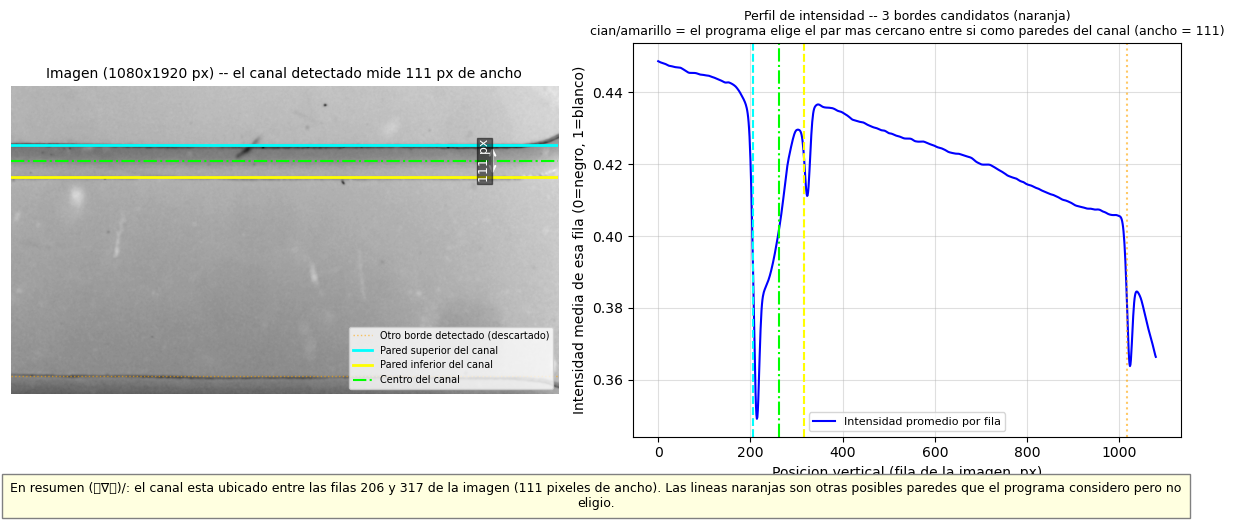

In [3]:
img_ref = ac.cargar_imagen_gris(ruta_referencia)

escala_um_por_px = None  
# Se coloca la calibración real, e.g. 0.65 (um por pixel), cuando se tenga... (es "opcional")

res_ref = ac.detectar_roi_desde_referencia(img_ref, escala_um_por_px=escala_um_por_px)

if res_ref ["exito"]:
    ancho_canal_ref = res_ref["ancho"]
    alto_px, ancho_px_img = res_ref["dimensiones_imagen_px"]
    print(f"Dimensiones de la imagen: {alto_px} x {ancho_px_img} px")
    print(f"Ancho de canal de referencia = {ancho_canal_ref} px", end="")
    if escala_um_por_px is not None:
        print(f"  (~{res_ref['ancho_um']:.1f} um)")
else:
    ancho_canal_ref = None
    print("No se detecto el ROI de referencia (˙◠˙):", res_ref["motivo"])
    print("  (define escala_um_por_px arriba para ver esto tambien en micrometros)")
plt.show()

#### **3° Validación de la detección de cada imagen antes de la calibración⭑.ᐟ**

ᯓ★ Correr primero esta celda para revisar visualmente si el detector encuentra el canal correctamente para blanco y maxima

**!! sobre todo para el blanco, que es el caso difícil debido al bajo contraste ¡¡**

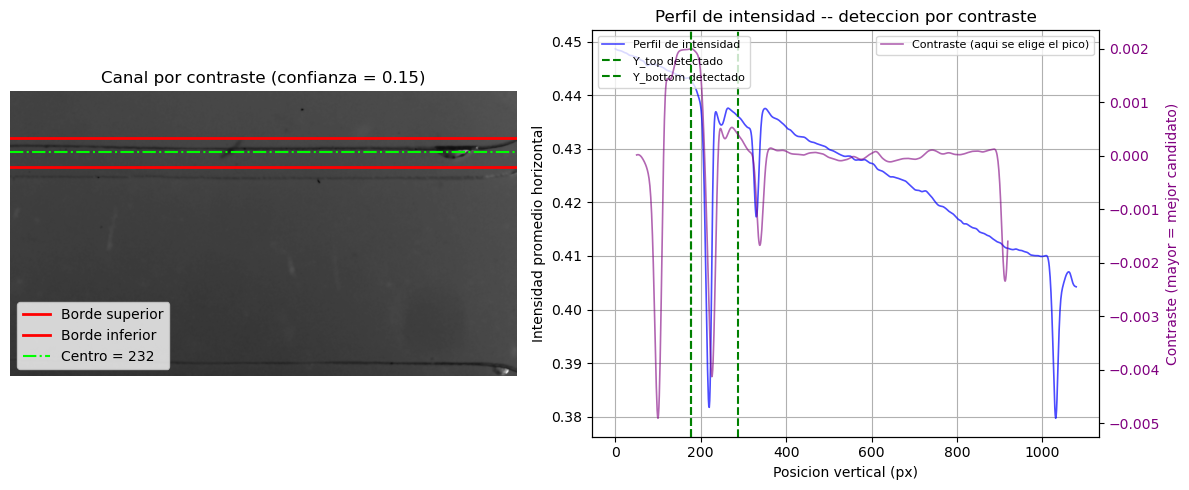

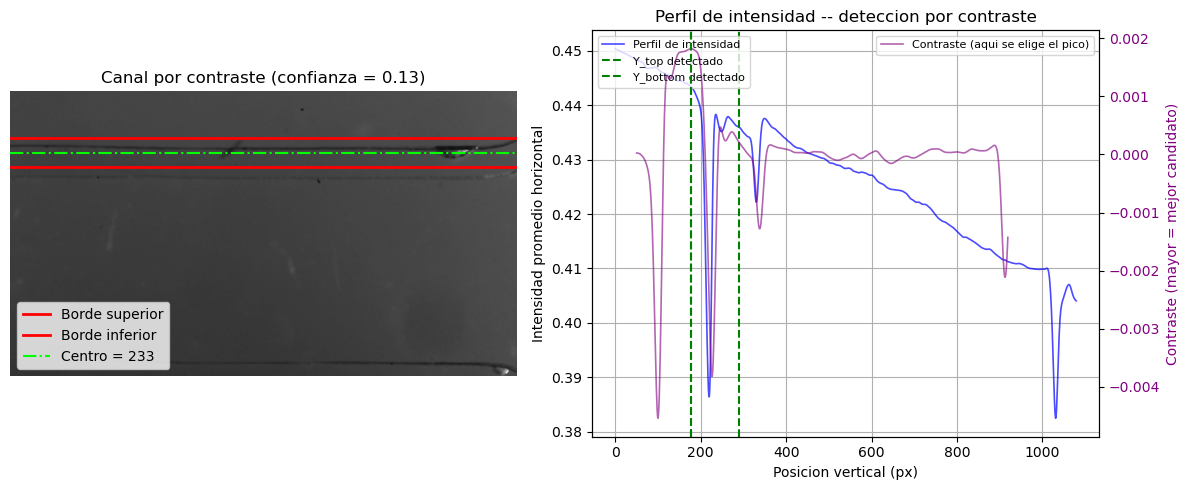

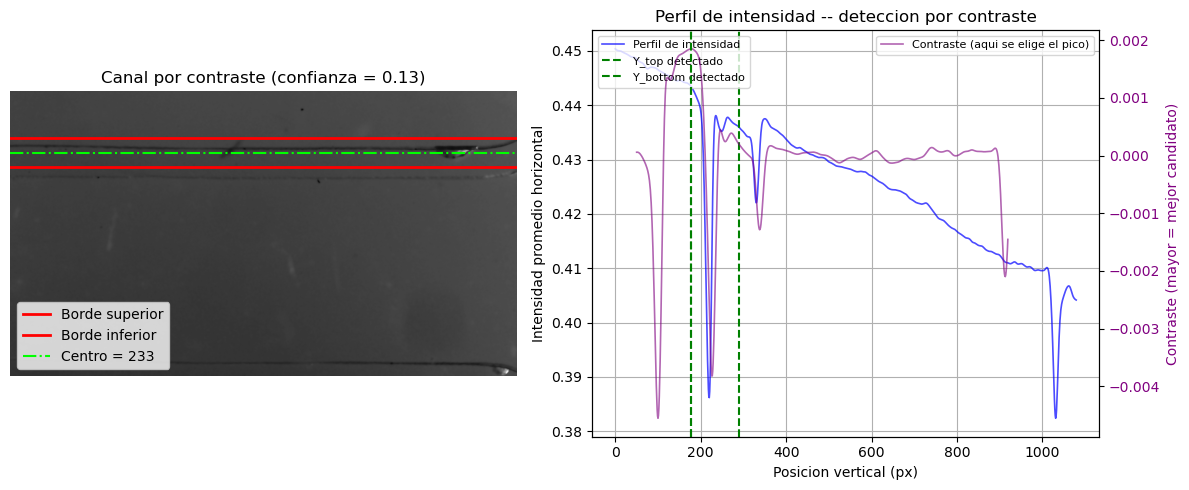

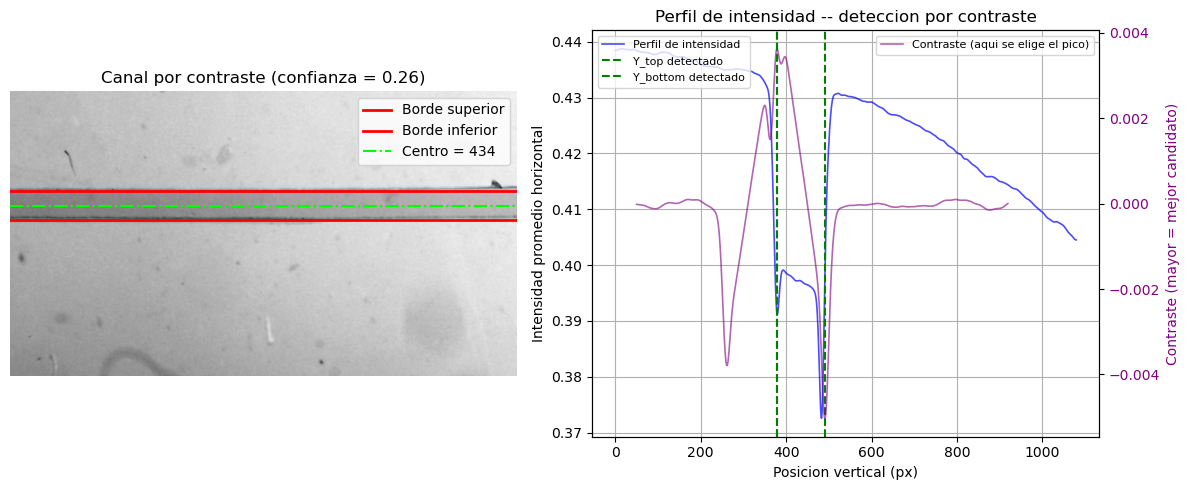

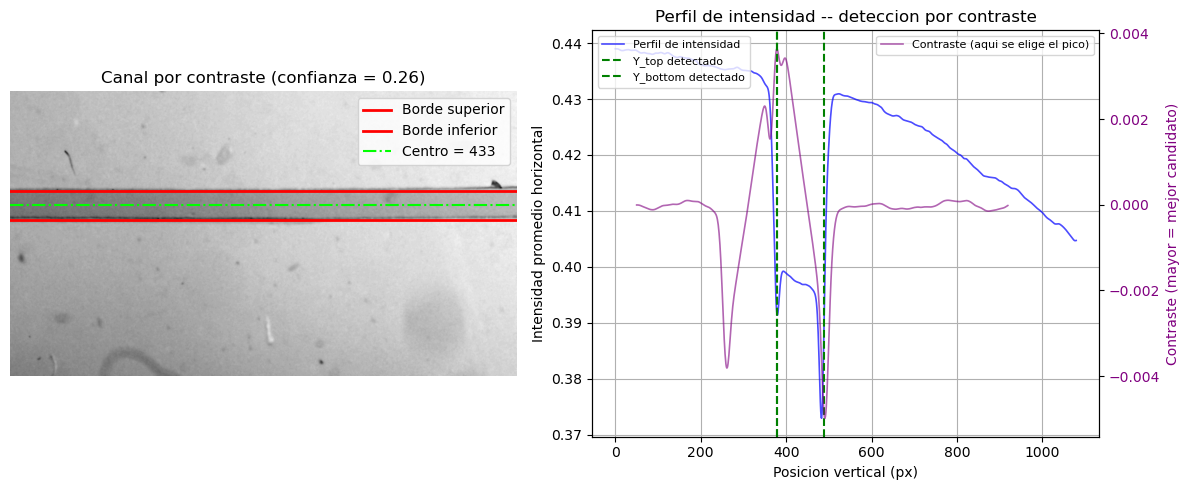

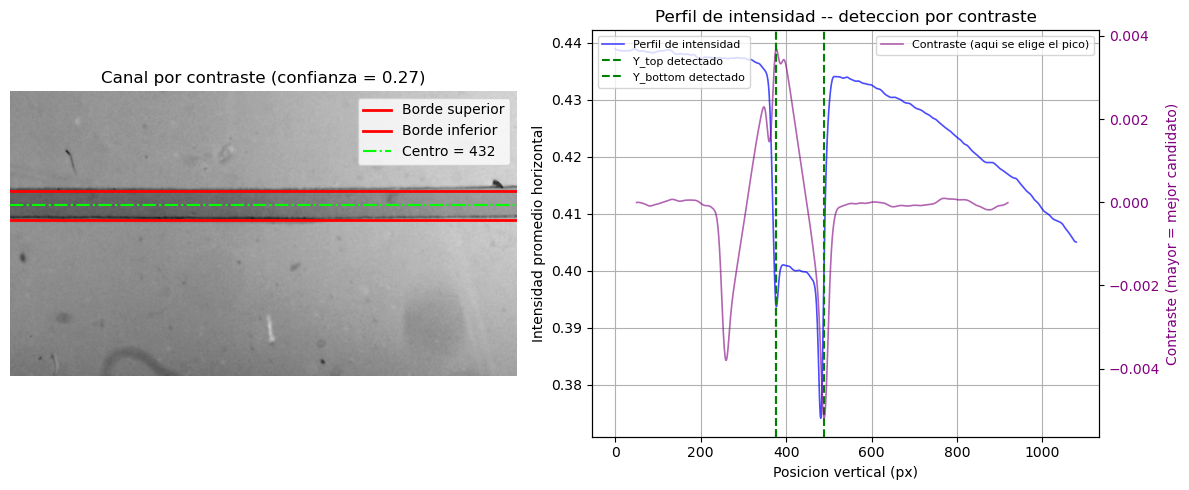

,grupo,imagen,y_top,y_bottom,confianza,estado
0,blanco,image10.bmp,177,288,0.15,REVISAR
1,blanco,image9.bmp,178,289,0.13,REVISAR
2,blanco,image8.bmp,178,289,0.13,REVISAR
3,maxima,image4.bmp,379,490,0.26,REVISAR
4,maxima,image3.bmp,378,489,0.26,REVISAR
5,maxima,image2.bmp,377,488,0.27,REVISAR


In [4]:
from IPython.display import display

def validar_grupo(nombre, rutas, ancho_canal_ref, canal_oscuro=True):
    filas = []
    for ruta in rutas:
        nombre_archivo = os.path.basename(ruta)
        img = ac.cargar_imagen_gris(ruta)
        res = ac.detectar_canal_por_contraste(img, ancho_canal_ref, canal_oscuro=canal_oscuro)
        if res["exito"]:
            plt.show()
            filas.append({"grupo": nombre, "imagen": nombre_archivo, "y_top": res["y_top"],
                          "y_bottom": res["y_bottom"], "confianza": round(res["confianza"], 2),
                          "estado": "OK" if res["confianza"] >= 1.0 else "REVISAR"})
        else:
            filas.append({"grupo": nombre, "imagen": nombre_archivo, "y_top": None,
                          "y_bottom": None, "confianza": None, "estado": f"(╭ರ_•́)!! NO DETECTO ({res['motivo']})"})
    return filas

if ancho_canal_ref is not None:
    filas = validar_grupo("blanco", rutas_blanco, ancho_canal_ref, canal_oscuro)
    filas += validar_grupo("maxima", rutas_maxima, ancho_canal_ref, canal_oscuro)
    tabla_validacion = pd.DataFrame(filas)
    display(tabla_validacion)
else:
    print("Primero corrige la detección de referencia (paso 2)( ◡̀_◡́)ᕤ")

#### **4° Constución de la calibración⭑.ᐟ**

Calibracion completa. R² = 0.9973
Concentracion = -782.6194 x Intensidad + 337.0783


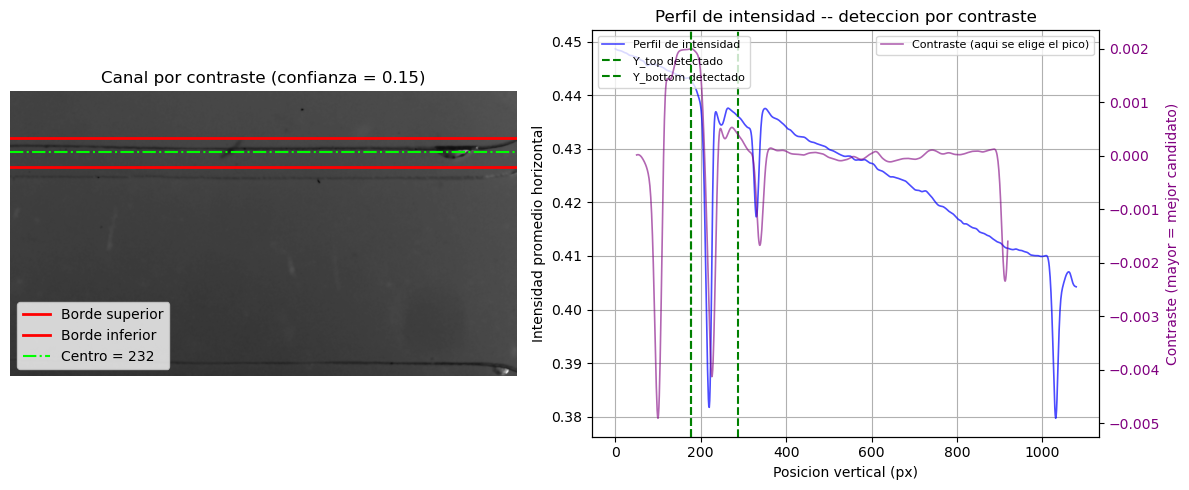

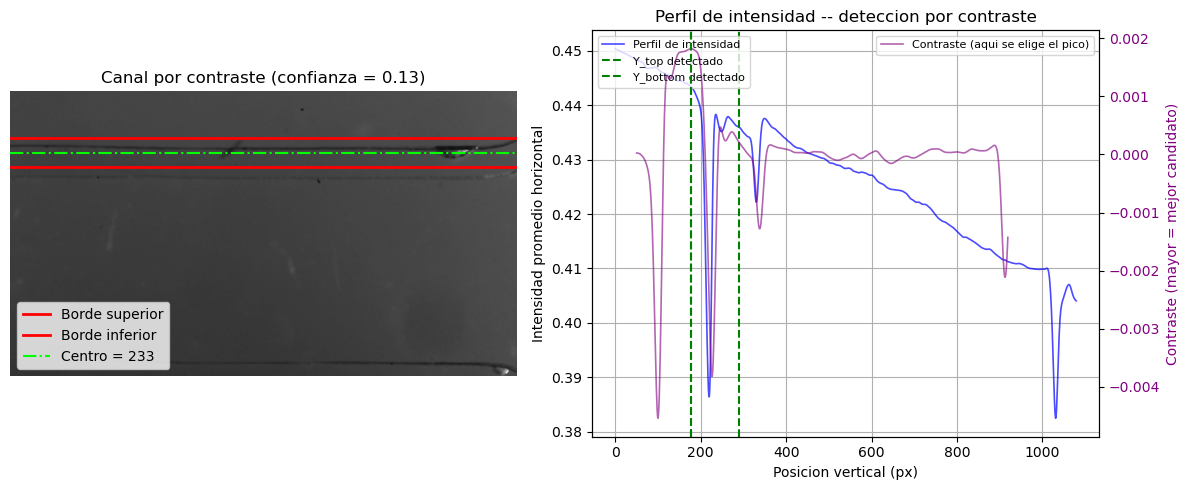

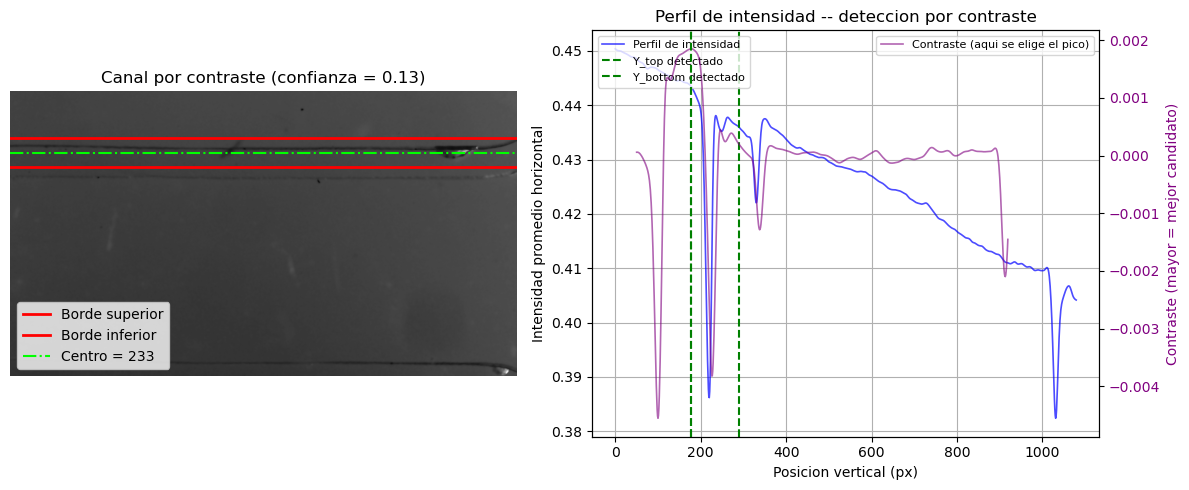

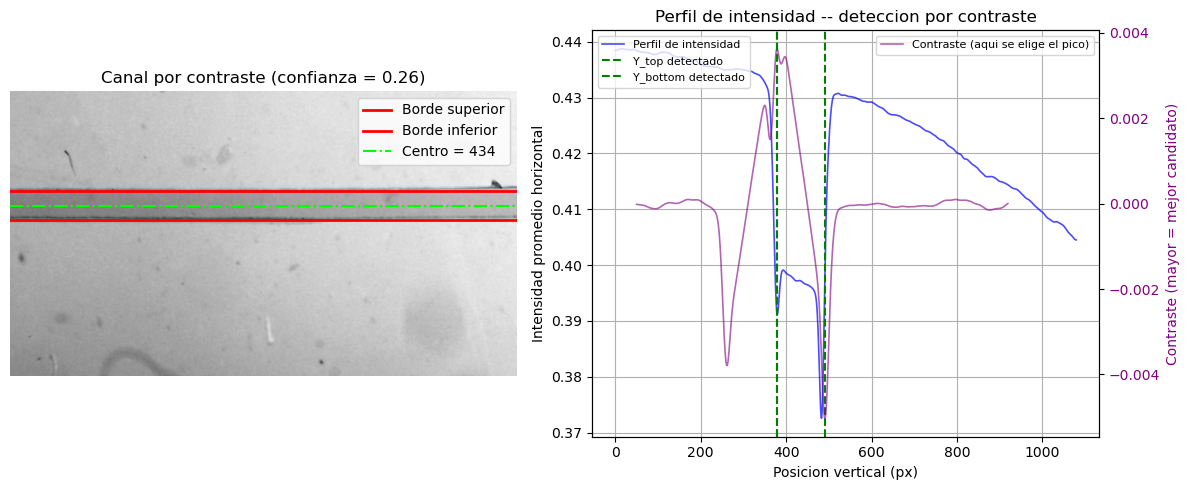

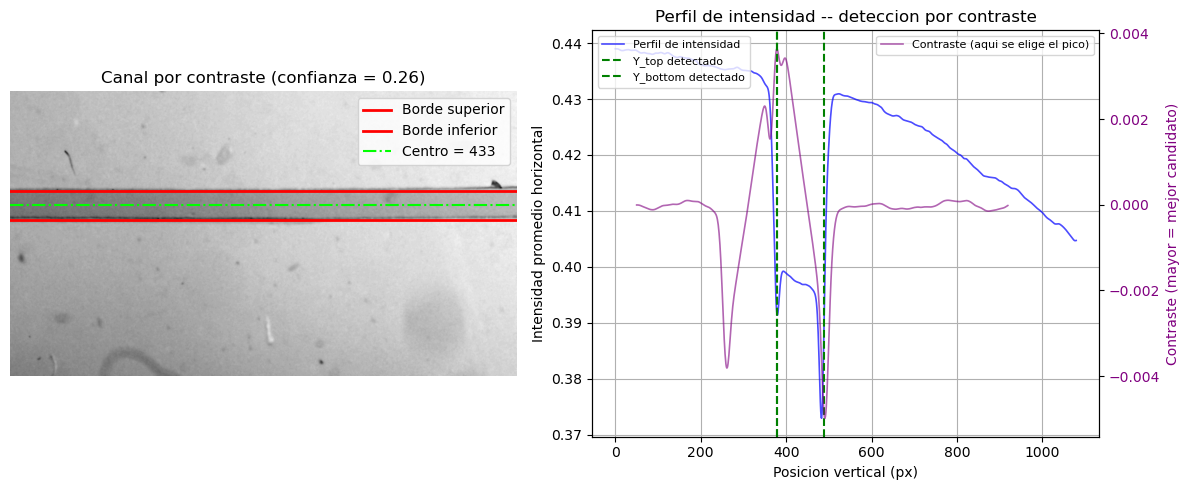

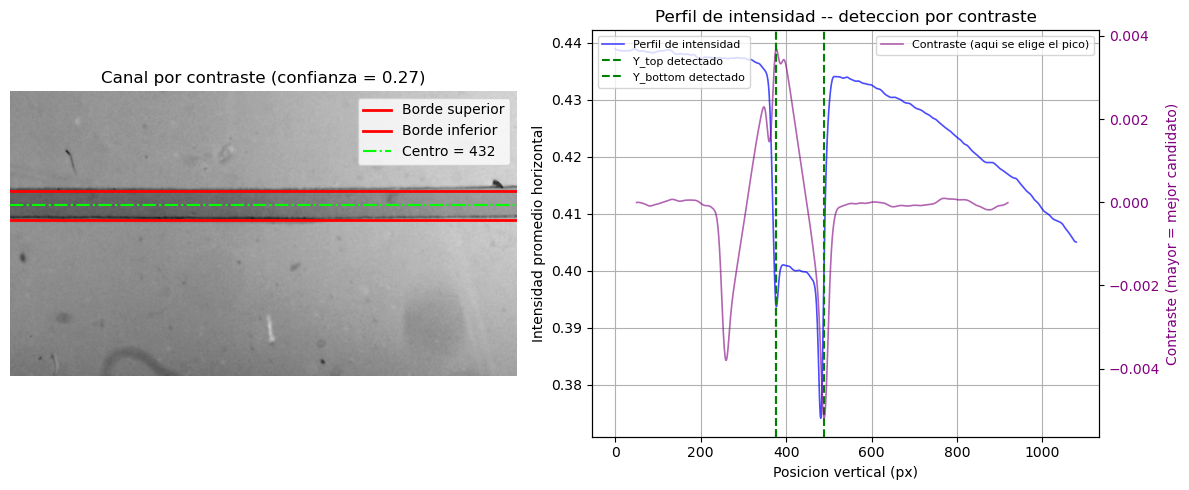

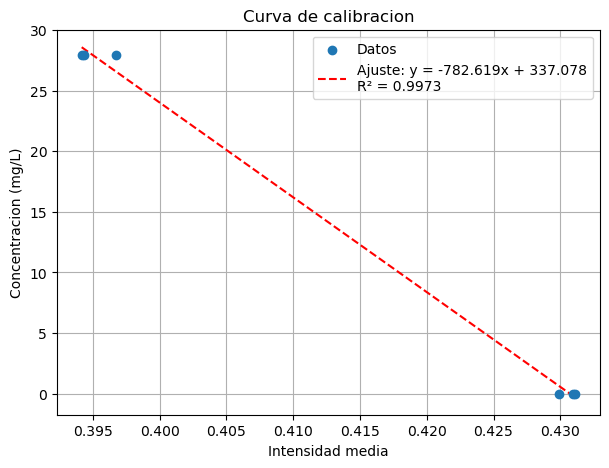

,grupo,replica,concentracion_objetivo,estado,intensidad,y_top,y_bottom,confianza
0,blanco,1,0.00,OK,0.429902,177,288,0.145261
1,blanco,2,0.00,OK,0.431089,178,289,0.131321
2,blanco,3,0.00,OK,0.430982,178,289,0.133293
3,maxima,1,27.92,OK,0.394170,379,490,0.259778
4,maxima,2,27.92,OK,0.394309,378,489,0.260508
5,maxima,3,27.92,OK,0.396755,377,488,0.268567


In [5]:
grupos = [
    {"nombre": "blanco", "concentracion": conc_blanco,
     "imagenes": [ac.cargar_imagen_gris(r) for r in rutas_blanco]},
    {"nombre": "maxima", "concentracion": conc_maxima,
     "imagenes": [ac.cargar_imagen_gris(r) for r in rutas_maxima]},
]

resultado = ac.construir_calibracion(grupos, ancho_canal_ref, canal_oscuro=canal_oscuro)

if resultado["exito"]:
    print(f"Calibracion completa. R\u00b2 = {resultado['r2']:.4f}")
    print(f"Concentracion = {resultado['slope']:.4f} x Intensidad + {resultado['intercept']:.4f}")
    plt.show()
    display(pd.DataFrame([{k: v for k, v in f.items() if k != 'figura'} for f in resultado["detalle"]]))
else:
    print("( •́ ᴖ`•̀) No se pudo calibrar:", resultado["motivo"])

#### **5° Aplicación de la calibración a la imagen con el gradiente de concentración⭑.ᐟ**

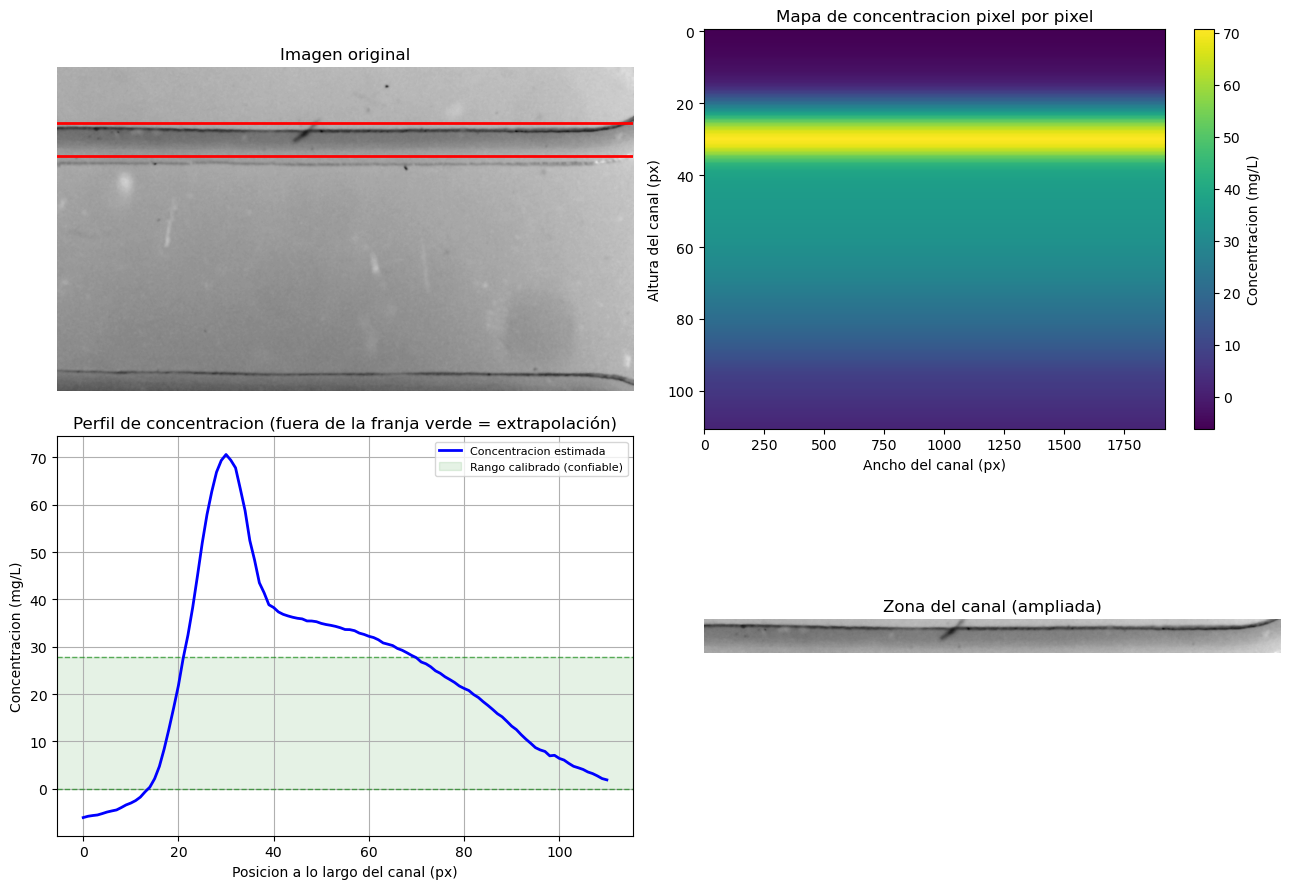

Concentracion media en el canal (imagen de gradiente) = 23.3040 mg/L
Porcentaje del perfil fuera del rango calibrado (extrapolacion) = 55.9%
(Ꞌꞌŏ_ŏ)!!Aviso: una parte importante del perfil queda fuera del rango calibrado¡¡ Interprete con discreción ദ്ദി(ᵕ—ᴗ—)


In [ ]:
if resultado["exito"]:
    img_gradiente = ac.cargar_imagen_gris(ruta_gradiente)
    res_grad = ac.procesar_gradiente(
        img_gradiente, resultado["slope"], resultado["intercept"],
        ancho_canal_ref, canal_oscuro=canal_oscuro,
        rango_valido=(conc_blanco, conc_maxima)
    )
    if res_grad["exito"]:
        plt.show()
        print(f"Concentracion media en el canal (imagen de gradiente) = {res_grad['concentracion_media']:.4f} mg/L")
        print(f"Porcentaje del perfil fuera del rango calibrado (extrapolacion) = {res_grad['porcentaje_fuera_de_rango']:.1f}%")

    if res_grad["porcentaje_fuera_de_rango"] > 20:
        print("(Ꞌꞌŏ_ŏ)!!Aviso: una parte importante del perfil queda fuera del rango calibrado¡¡ InterpreteS con discreción ദ്ദി(ᵕ—ᴗ—)")
    else:
        print("No se pudo procesar el gradiente:", res_grad["motivo"])
else:
    print("Primero completa la calibracion (paso 4) (ᴖ_ᴖ¨)╮")